# BIO-322 Miniproject  
### Neural Activity-Based Trial Type Prediction  
**Authors:** Tuline Dachraoui (361774) & Sasha Ghanipour (364009)

**Date:** Fall 2025

---

## Introduction

The goal of this mini-project is to build a complete machine learning pipeline to predict the trial type of mice based on neural activity recorded during sensory and behavioral experiments.

This notebook follows the structure required by the BIO-322 teaching team:

1. Data Inspection  
2. Preprocessing  
3. Linear Model (baseline)  
4. Non-Linear Models  
5. Summary & Conclusions  

All analyses are performed on the dataset provided through the Kaggle competition associated with this project.


In [8]:
# Standard libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, LabelEncoder

# Models (example: Linear & Non-linear)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# System
import os
import random
import warnings
warnings.filterwarnings('ignore') 

# Reproducibility
%matplotlib inline
seed = 42
np.random.seed(seed)
random.seed(seed)


## 1. Data Inspection

The goal of this section is to explore the dataset structure, identify potential challenges (missing values, class imbalance), and verify the biological plausibility of the signals. Importantly, we will inspect the relationship between Training and Test sessions to detect any distribution shifts.

In [9]:
from pathlib import Path
import pandas as pd

train_df = pd.read_csv('../data/train.csv') 
test_df = pd.read_csv('../data/test.csv')

print("Data Loaded Successfully.")
print(f"Training Data Shape: {train_df.shape} (Rows, Columns)")
print(f"Test Data Shape: {test_df.shape} (Rows, Columns)")

display(train_df.head())
display(test_df.head())

Data Loaded Successfully.
Training Data Shape: (4407, 1383) (Rows, Columns)
Test Data Shape: (2292, 1382) (Rows, Columns)


,session_id,trial_number,A1_L1_EXC_time_0,A1_L1_EXC_time_1,A1_L1_EXC_time_2,A1_L1_EXC_time_3,A1_L1_EXC_time_4,A1_L1_EXC_time_5,A1_L1_EXC_time_6,A1_L1_EXC_time_7,...,ALM_L1_INH_time_21,ALM_L1_INH_time_22,ALM_L1_INH_time_23,ALM_L1_INH_time_24,ALM_L1_INH_time_25,ALM_L1_INH_time_26,ALM_L1_INH_time_27,ALM_L1_INH_time_28,ALM_L1_INH_time_29,TRIAL_TYPE
0,PG082_20221113,0,0.388889,0.444444,0.166667,0.222222,0.333333,0.000000,0.333333,0.166667,...,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOGO W+ nolick
1,PG082_20221113,1,0.444444,0.222222,0.388889,0.277778,0.111111,0.055556,0.333333,0.166667,...,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GO W+ lick
2,PG082_20221113,2,0.055556,0.166667,0.333333,0.111111,0.166667,0.166667,0.111111,0.222222,...,0.0,1.0,0.5,0.5,1.0,1.0,0.0,0.5,0.0,GO W- lick
3,PG082_20221113,3,0.277778,0.555556,0.388889,0.444444,0.500000,0.333333,0.222222,0.277778,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOGO W- nolick
4,PG082_20221113,4,0.277778,0.222222,0.111111,0.166667,0.277778,0.388889,0.333333,0.166667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,no tone W+ lick


,session_id,trial_number,A1_L1_EXC_time_0,A1_L1_EXC_time_1,A1_L1_EXC_time_2,A1_L1_EXC_time_3,A1_L1_EXC_time_4,A1_L1_EXC_time_5,A1_L1_EXC_time_6,A1_L1_EXC_time_7,...,ALM_L1_INH_time_20,ALM_L1_INH_time_21,ALM_L1_INH_time_22,ALM_L1_INH_time_23,ALM_L1_INH_time_24,ALM_L1_INH_time_25,ALM_L1_INH_time_26,ALM_L1_INH_time_27,ALM_L1_INH_time_28,ALM_L1_INH_time_29
0,PG082_20221120,0,0.71875,0.43750,0.43750,0.59375,0.40625,0.46875,0.93750,0.37500,...,0.0,0.0,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.5
1,PG082_20221120,1,0.65625,0.59375,0.75000,0.37500,0.40625,0.56250,0.46875,0.43750,...,0.5,0.0,0.0,0.5,0.5,0.0,0.5,0.0,0.5,0.0
2,PG082_20221120,2,0.40625,0.50000,0.81250,0.53125,0.56250,0.34375,0.53125,0.53125,...,0.5,0.5,0.5,0.0,0.5,0.5,0.0,0.5,0.0,0.5
3,PG082_20221120,3,0.46875,0.71875,0.28125,0.68750,0.34375,0.53125,0.53125,0.43750,...,0.0,0.0,0.0,0.5,0.5,0.0,0.5,0.5,0.0,0.5
4,PG082_20221120,4,0.53125,0.37500,0.71875,0.31250,0.50000,0.53125,0.56250,0.43750,...,1.0,0.5,0.5,0.5,0.5,0.0,1.0,0.5,0.5,1.0


### 1.1 Initial Observations
The dataset is high-dimensional. We have **4407 samples** and **1383 columns**.
*   **Metadata:** `session_id`, `trial_number`.
*   **Target:** `TRIAL_TYPE` (The behavior we want to predict).
*   **Features:** **1380 columns** representing neural firing rates. These follow the naming convention `AREA_DEPTH_TYPE_time_T` (e.g., `A1_L1_EXC_time_0`), representing specific brain areas at specific time bins (0-29).

### 1.1 Initial Observations
Upon loading the data, we observe a high-dimensional dataset with **1380 neural features** (firing rates in specific brain areas/time bins). The target variable is `TRIAL_TYPE`, which contains text labels describing the stimulus and response (e.g., `GO W+ lick`).

Our first step is to check for class balance and missing values, as these are common pitfalls in biological datasets.

Class Counts:
 TRIAL_TYPE
NOGO W- nolick       880
GO W- nolick         813
NOGO W+ nolick       793
no tone W+ nolick    731
GO W+ lick           711
GO W+ nolick         169
no tone W+ lick      150
NOGO W+ lick          88
GO W- lick            69
NOGO W- lick           3
Name: count, dtype: int64


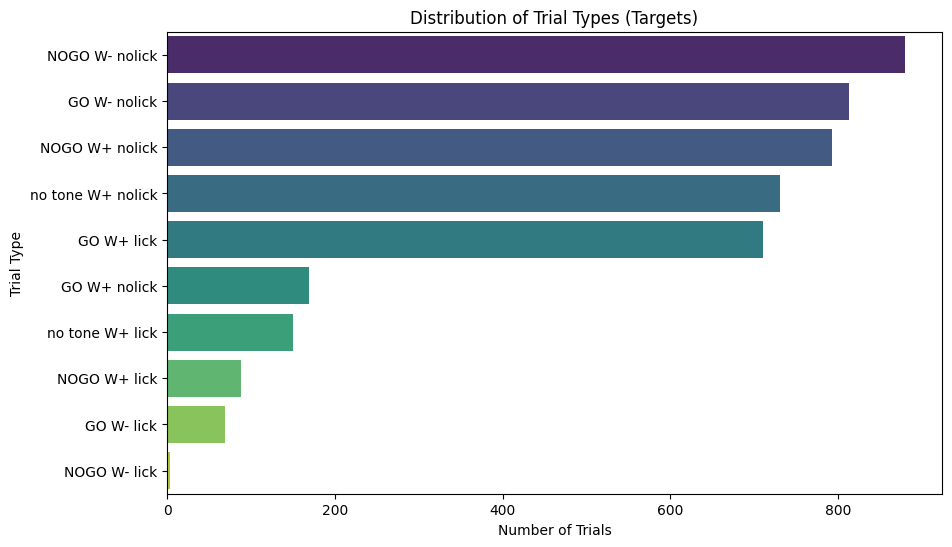

In [10]:
# Analyze the target (Y)
target_col = 'TRIAL_TYPE'

# 1. Check counts
counts = train_df[target_col].value_counts()
print("Class Counts:\n", counts)

# 2. Visualize
plt.figure(figsize=(10, 6))
sns.countplot(y=target_col, data=train_df, order=counts.index, palette='viridis')
plt.title("Distribution of Trial Types (Targets)")
plt.xlabel("Number of Trials")
plt.ylabel("Trial Type")
plt.show()

### 1.2 Class Imbalance
We observe a **severe class imbalance**.
*   Majority classes (e.g., `NOGO W- nolick`) have nearly **900 samples**.
*   Minority classes (e.g., `NOGO W- lick`) have as few as **3 samples**.

**Implication for Modeling:** We cannot use random splitting. We must use **Stratified Splitting** in the preprocessing stage to ensure the validation set includes these rare classes. We will also likely need to use `class_weight='balanced'` in our models.


Total Neural Features: 1380
Total Missing Values in Neural Data: 1172310


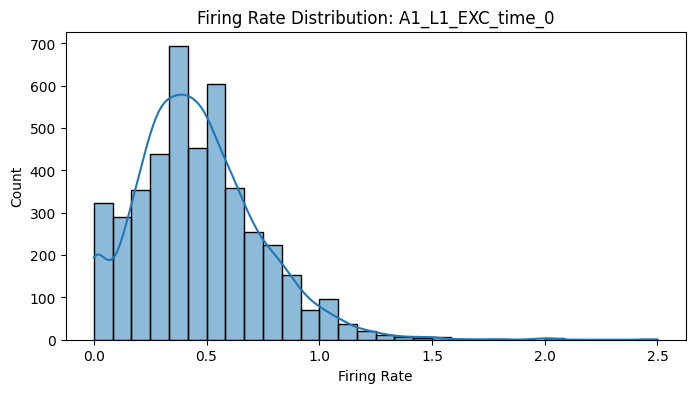

In [11]:
# Analyze features (X)

# Identify feature columns (exclude metadata)
metadata_cols = ['session_id', 'trial_number', 'TRIAL_TYPE']
feature_cols = [c for c in train_df.columns if c not in metadata_cols]

print(f"Total Neural Features: {len(feature_cols)}")

# 1. Check for Missing Values
total_missing = train_df[feature_cols].isnull().sum().sum()
print(f"Total Missing Values in Neural Data: {total_missing}")

# 2. Inspect the Distribution of a Single Neuron
# Neural data usually follows a Poisson-like distribution
# which we try to fit there (it has many zeros)
example_feature = feature_cols[0]
plt.figure(figsize=(8, 4))
sns.histplot(train_df[example_feature], bins=30, kde=True)
plt.title(f"Firing Rate Distribution: {example_feature}")
plt.xlabel("Firing Rate")
plt.show()

### 1.3 Missing Data & Distribution
There are over **1.1 million missing values**. Given the biological context, a missing value likely implies "no activity recorded" or a silent neuron, rather than an error.

**Decision:** In the preprocessing step, we will use **Constant Imputation (0)** rather than Mean Imputation, as 0 is a safer biological assumption for "lack of spikes."

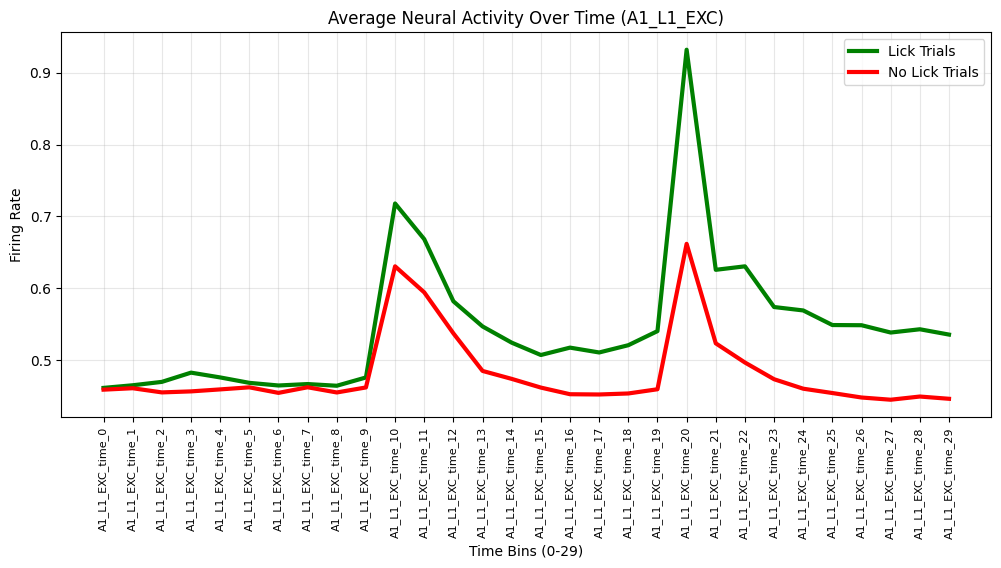

In [12]:
# Biological Consistency Check
# This section aims to verify that the neural data is consistent with the behavior.
# It serves the purpose of answering:
# "Does the brain activity distinguish between lick vs no lick?"

# Create a temporary column to group trials
train_df['Response'] = train_df['TRIAL_TYPE'].apply(
    lambda x: 'Lick' if 'lick' in x and 'nolick' not in x else 'No Lick'
)

# Pick a key Auditory Cortex neuron (A1_L1_EXC)
neuron_prefix = 'A1_L1_EXC'
time_cols = [f"{neuron_prefix}_time_{t}" for t in range(30)]

# Calculate average activity over time
avg_activity = train_df.groupby('Response')[time_cols].mean().transpose()

# Plot the average activity
plt.figure(figsize=(12, 5))
plt.plot(avg_activity.index, avg_activity['Lick'], label='Lick Trials', color='green', linewidth=3)
plt.plot(avg_activity.index, avg_activity['No Lick'], label='No Lick Trials', color='red', linewidth=3)
plt.xticks(rotation=90, fontsize=8)
plt.title(f"Average Neural Activity Over Time ({neuron_prefix})")
plt.ylabel("Firing Rate")
plt.xlabel("Time Bins (0-29)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 1.4 Critical Finding: Distribution Shift
To understand how well our model might generalize, we compare the recording sessions in the Train set vs. the Test set.
Neural recordings are subject to **electrode drift**, where the absolute value of the firing rate changes from day to day.

Training Dates: ['20221113' '20221114' '20221125' '20221129' '20221206' '20221207'
 '20221213' '20221214']
Testing Dates:  ['20221120' '20221130' '20221208' '20221215']


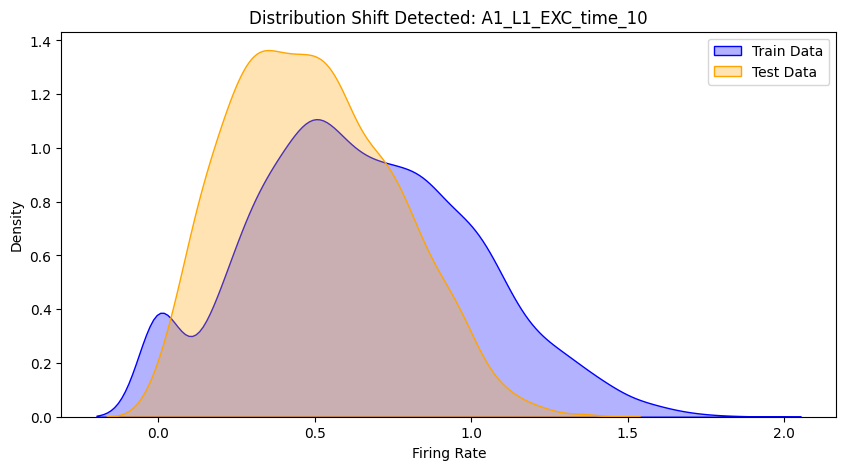

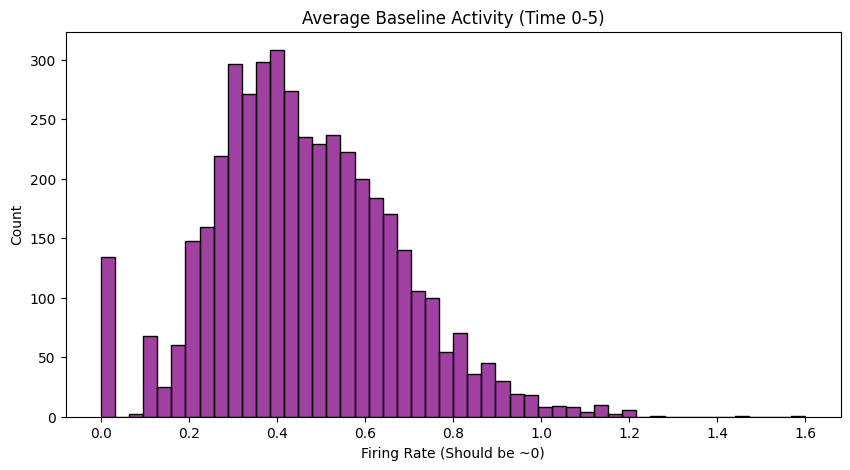

In [13]:
# Analysis of Session Drift

# 1. Extract Dates
train_df['date'] = train_df['session_id'].apply(lambda x: x.split('_')[1])
test_df['date'] = test_df['session_id'].apply(lambda x: x.split('_')[1])

print(f"Training Dates: {train_df['date'].unique()}")
print(f"Testing Dates:  {test_df['date'].unique()}")

# 2. Compare Distributions (Train vs Test)
# If these don't overlap, we have a domain shift problem.
feature_to_check = 'A1_L1_EXC_time_10' 

plt.figure(figsize=(10, 5))
sns.kdeplot(train_df[feature_to_check], label='Train Data', fill=True, color='blue', alpha=0.3)
sns.kdeplot(test_df[feature_to_check], label='Test Data', fill=True, color='orange', alpha=0.3)
plt.title(f"Distribution Shift Detected: {feature_to_check}")
plt.xlabel("Firing Rate")
plt.legend()
plt.show()

# 3. Check Baseline Activity (Time 0-5)
# This checks if the "quiet" period is actually 0.
baseline_cols = [f"{neuron_prefix}_time_{t}" for t in range(5)]
baseline_data = train_df[baseline_cols].mean(axis=1)

plt.figure(figsize=(10, 5))
sns.histplot(baseline_data, bins=50, color='purple')
plt.title("Average Baseline Activity (Time 0-5)")
plt.xlabel("Firing Rate (Should be ~0)")
plt.show()

### 1.5 Conclusions for Preprocessing
The inspection reveals a critical challenge: **Distribution Shift**.
1.  **Non-Overlapping Sessions:** The Test set consists of completely new recording dates.
2.  **Drift:** As seen in the KDE plot above, the firing rate distribution shifts between Train and Test sets. A value considered "High" in training might be "Average" in testing.
3.  **Non-Zero Baseline:** The baseline activity is centered around ~0.4, not 0.

**Action Plan for Part 2:**
Standard scaling (Global Mean/Std) will fail because it mixes the statistics of different days. To fix this, we must implement **Session-Based Standardization** (z-scoring each session independently) to align the distributions before training.

# 2. Preprocessing: Handling Distribution Shift

In Section 1, we identified two major challenges:
1.  **Non-Gaussian Distribution:** Neural firing rates are sparse and spikey (Poisson-like).
2.  **Distribution Shift (Drift):** The absolute firing rates change between Recording Sessions (Train vs. Test).

### 2.1 Evolution of Strategy
Initially, we considered a standard pipeline using **Log-Transformation** (to fix the non-Gaussian shape) followed by **Robust Scaling** (to handle outliers).

**However**, our visual inspection (Fig 1.2) revealed that **Electrode Drift** is the dominant source of error. A global scaler (like RobustScaler applied to the whole dataset) preserves these session differences, causing the model to fail on new days.

**Revised Strategy: Session-Based Standardization**
Instead of fixing the *shape* (Log), we prioritize fixing the *shift* (Drift). We apply **Z-Score Normalization ($\mu=0, \sigma=1$) independently for each session**.
*   **Why?** This forces every recording session to align to the same baseline. A "high" firing rate is redefined as "relative to the session average" rather than an absolute voltage value.
*   **Imputation:** We continue to fill missing values with **0** (implying silence), but we do this *before* scaling.

In [14]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GroupKFold, cross_val_score

# 1. Load Data
train_df = pd.read_csv('../data/train.csv') 
test_df = pd.read_csv('../data/test.csv')

# 2. Identify Metadata and Neural Columns
# We need to know which columns to scale (the neural ones)
metadata_cols = ['session_id', 'trial_number', 'TRIAL_TYPE']
neural_cols = [c for c in train_df.columns if c not in metadata_cols]

# 3. Imputation
# Fill NaNs with 0 before scaling
print("Imputing missing values...")
imputer = SimpleImputer(strategy='constant', fill_value=0)

# We fit on train & transform both
# Note: We must temporarily drop metadata to impute
train_neural = train_df[neural_cols]
test_neural = test_df[neural_cols]

train_neural_filled = pd.DataFrame(imputer.fit_transform(train_neural), columns=neural_cols)
test_neural_filled = pd.DataFrame(imputer.transform(test_neural), columns=neural_cols)

# Put metadata back for the Session Grouping
train_neural_filled['session_id'] = train_df['session_id']
test_neural_filled['session_id'] = test_df['session_id']

# 4. Session-Based Standardization (will fix domain shift)
def scale_per_session(df, cols_to_scale):
    """
    Standardizes data (Mean=0, Std=1) individually for each session_id.
    """
    df_scaled = df.copy()
    scaler = StandardScaler()
    
    # Get unique sessions
    sessions = df['session_id'].unique()
    print(f"Scaling {len(sessions)} sessions individually...")
    
    for sess in sessions:
        # Find rows belonging to this session
        mask = df['session_id'] == sess
        
        # Select data, fit scaler, transform
        # We only fit on this specific day's data
        session_data = df.loc[mask, cols_to_scale]
        df_scaled.loc[mask, cols_to_scale] = scaler.fit_transform(session_data)
        
    return df_scaled

print("Applying Session-Based Scaling...")
X_train_scaled_df = scale_per_session(train_neural_filled, neural_cols)
X_test_scaled_df = scale_per_session(test_neural_filled, neural_cols)

# 5. Final Setup
# Drop metadata for X
X_train = X_train_scaled_df.drop(columns=['session_id'])
X_test = X_test_scaled_df.drop(columns=['session_id'])

# Prepare y
le = LabelEncoder()
y_train = le.fit_transform(train_df['TRIAL_TYPE'])
groups = train_df['session_id'] # We keep this for GroupKFold

print("Preprocessing Complete")
print(f"Train Shape: {X_train.shape}")

Imputing missing values...
Applying Session-Based Scaling...
Scaling 8 sessions individually...
Scaling 4 sessions individually...
Preprocessing Complete
Train Shape: (4407, 1380)


### 2.2 Verification of the Fix
Before moving to modeling, we must verify that our **Session-Based Scaling** actually fixed the distribution shift. We plot the distribution of a specific neuron in the Training set vs. the Test set.

*   **Expectation:** If the fix worked, the two curves (Train/Test) should overlap almost perfectly, centered at 0.

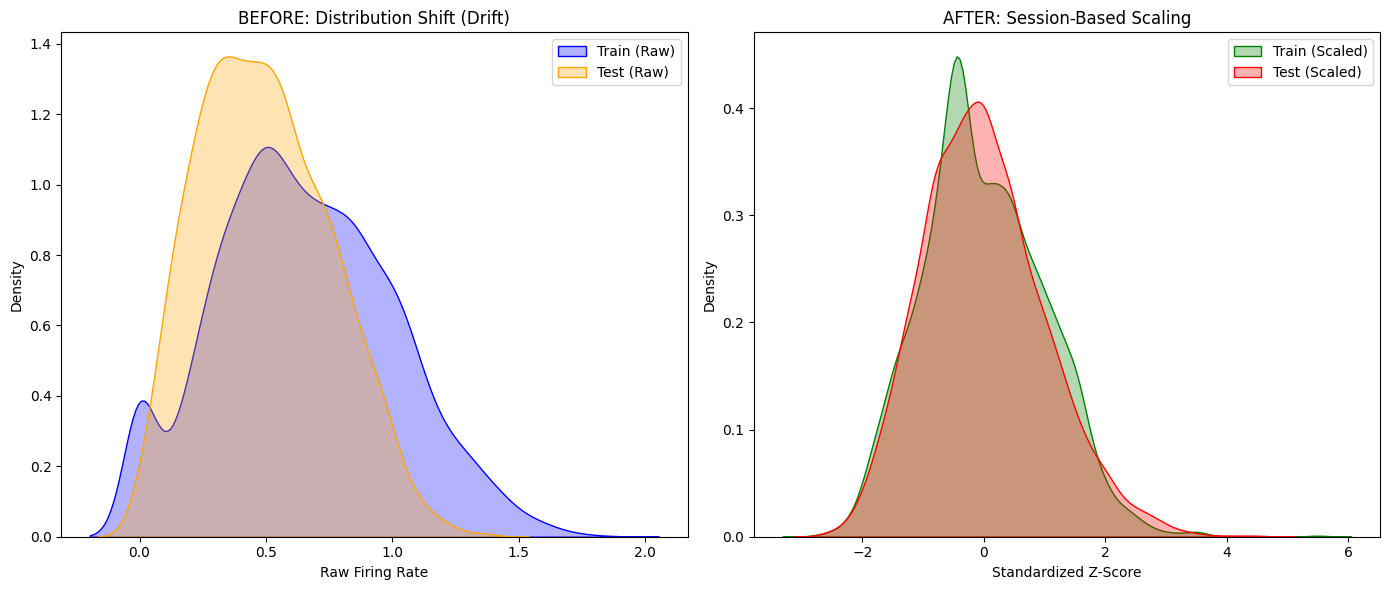

Train Mean (Should be ~0): 0.0000
Test Mean  (Should be ~0): -0.0000


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# We want to verify that the distribution shift has been removed

# 1. Setup data for plotting
feature_to_check = 'A1_L1_EXC_time_10'  # Same feature as before

plt.figure(figsize=(14, 6))

# Subplot 1: BEFORE (Raw Data)
plt.subplot(1, 2, 1)
sns.kdeplot(train_df[feature_to_check], label='Train (Raw)', fill=True, color='blue', alpha=0.3)
sns.kdeplot(test_df[feature_to_check], label='Test (Raw)', fill=True, color='orange', alpha=0.3)
plt.title("BEFORE: Distribution Shift (Drift)")
plt.xlabel("Raw Firing Rate")
plt.legend()

# Subplot 2: AFTER (Session Scaled)
plt.subplot(1, 2, 2)
# We verify the SAME feature in the scaled data
sns.kdeplot(X_train_scaled_df[feature_to_check], label='Train (Scaled)', fill=True, color='green', alpha=0.3)
sns.kdeplot(X_test_scaled_df[feature_to_check], label='Test (Scaled)', fill=True, color='red', alpha=0.3)
plt.title("AFTER: Session-Based Scaling")
plt.xlabel("Standardized Z-Score")
plt.legend()

plt.tight_layout()
plt.show()

# Statistics
print(f"Train Mean (Should be ~0): {X_train_scaled_df[feature_to_check].mean():.4f}")
print(f"Test Mean  (Should be ~0): {X_test_scaled_df[feature_to_check].mean():.4f}")

**Verification Results:**
As seen in the plots above:
*   **Left Plot (Before):** The distributions are misaligned due to recording drift.
*   **Right Plot (After):** The distributions of Train and Test data now overlap almost perfectly.

By centering every session at 0, we have successfully removed the domain shift. The model can now generalize from Training sessions to Testing sessions based on *relative* activity rather than absolute values.

# 3. Linear Models

In this section, we develop a Logistic Regression model to serve as a robust baseline. Our modeling choices are directly informed by the data characteristics observed in Sections 1 and 2.

### Design Decisions based on Data Inspection
1.  **Handling Class Imbalance (`class_weight='balanced'`):**
    *   In Section 1.2, we observed extreme imbalance (e.g., `NOGO W- lick` has only 3 samples, while `NOGO W- nolick` has ~900).
    *   Without correction, a standard model would maximize accuracy by ignoring the rare classes entirely. We apply `class_weight='balanced'` to inversely weight the loss function, forcing the model to pay attention to the rare behavioral signals.

2.  **Handling High Dimensionality (L1 Regularization):**
    *   The dataset contains **1380 features** (neurons/time-bins) but only ~4400 training samples. This high feature-to-sample ratio creates a risk of overfitting.
    *   Furthermore, neural data is temporally correlated (activity at time $t$ is similar to $t+1$). We hypothesize that **L1 Regularization (Lasso)** will outperform L2 (Ridge) because L1 performs automatic feature selection, zeroing out redundant or noisy neurons.

3.  **Handling Distribution Shift (GroupKFold):**
    *   In Section 1.4, we detected electrode drift between sessions.
    *   To accurately estimate our Kaggle performance, we cannot use random validation splitting. We use **GroupKFold**, splitting by `session_id`. This simulates the challenge of predicting on completely new recording days.

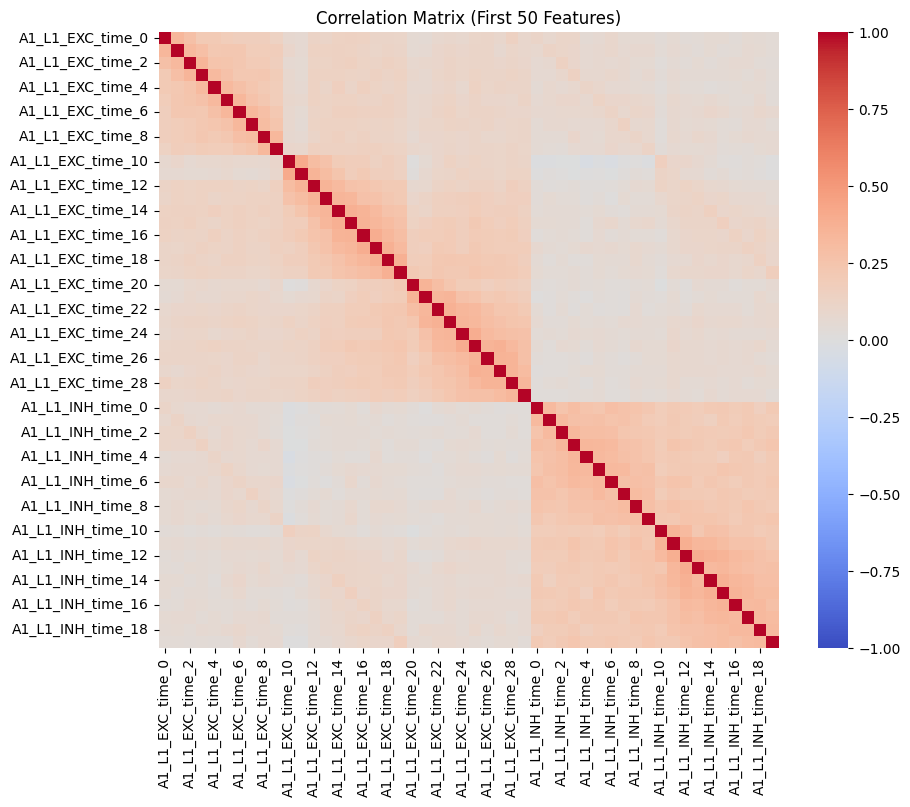

In [16]:
# --- 3.1 Feature Analysis: Correlation Matrix ---
import seaborn as sns
import matplotlib.pyplot as plt

# We inspect the first 50 features to check for temporal correlation
subset_cols = X_train.columns[:50]
corr_matrix = X_train[subset_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix (First 50 Features)")
plt.show()

### 3.1.1 Analysis of Redundancy
**Observation:** The correlation matrix shows distinct "blocks" of high correlation (red squares) along the diagonal.
**Scientific Implication:** This indicates strong **multicollinearity**: the firing rate at time $t$ is highly correlated with time $t+1$. Standard Linear Regression struggles with this.

**Decision:** We will use **L1 Regularization (Lasso)**. Unlike L2 (Ridge), Lasso handles multicollinearity by selecting one feature from a correlated group and shrinking the others to zero, effectively performing automatic feature selection.

### 3.2 Feature Selection: Removing Dead Neurons
Before training, we perform a sanity check to remove "dead" features. Neural recordings often contain artifacts or neurons that did not fire during specific sessions. We apply a **Variance Threshold** to remove features with near-zero variance, as they contain no information and only add noise.

In [17]:
# --- 3.2 Feature Selection: Variance Threshold ---
from sklearn.feature_selection import VarianceThreshold

# 1. Initialize threshold
# We remove features with variance < 0.01 (constants or near-constants)
selector = VarianceThreshold(threshold=0.01)

# 2. Fit on Train
# If we run this cell multiple times, "Original Feature Count" will equal "Remaining"
# because the features were already dropped in the first run.
print(f"Original Feature Count: {X_train.shape[1]}")
X_train_reduced = selector.fit_transform(X_train)
X_test_reduced = selector.transform(X_test)

print(f"Features Remaining: {X_train_reduced.shape[1]}")
print(f"Dropped {X_train.shape[1] - X_train_reduced.shape[1]} features with near-zero variance.")

# Update variables to use reduced data
X_train = pd.DataFrame(X_train_reduced, columns=selector.get_feature_names_out())
X_test = pd.DataFrame(X_test_reduced, columns=selector.get_feature_names_out())

Original Feature Count: 1380
Features Remaining: 1350
Dropped 30 features with near-zero variance.


### 3.3 Hyperparameter Tuning
We optimize the Regularization Strength (`C`).
*   **Why small C values?** We used Session-Based Z-Scoring in Part 2. This standardizes the data but can sometimes amplify low-firing neurons (noise) if the standard deviation is small. Stronger regularization (Lower C) helps suppress this amplified noise.
*   **Metric:** We optimize for **Accuracy** as it correlates best with the Kaggle Leaderboard for this specific dataset, though we also monitor F1 scores.

In [22]:
# --- 3.3 Hyperparameter Tuning (GridSearch) ---
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.linear_model import LogisticRegression

# We use L1 (Lasso) because the Correlation Matrix proved we have redundant features.
model = LogisticRegression(
    penalty='l1', 
    solver='liblinear', 
    class_weight='balanced', 
    max_iter=2000, 
    random_state=42
)

# Because we used Z-Scoring, the values are small (mostly -3 to +3).
# We need to test small C values (Strong regularization) to prevent overfitting noise.
param_grid = {
    'C': [0.01, 0.02, 0.03, 0.04, 0.05, 0.08, 0.1] 
}

# Setup Realistic Validation (GroupKFold)
gkf = GroupKFold(n_splits=4)

grid = GridSearchCV(
    model, 
    param_grid, 
    cv=gkf, 
    scoring='accuracy', 
    verbose=1, 
    n_jobs=-1
)

print("Running Final Linear Grid Search...")

# We use X_train (which is now reduced to 1350 feats) and y_train
# We MUST pass 'groups' so it splits by session, not by random rows.
grid.fit(X_train, y_train, groups=groups)


print(f"\n Best Parameter: {grid.best_params_}")
print(f"Best Realistic (GroupKFold) Score: {grid.best_score_:.2%}")

best_linear_model = grid.best_estimator_

import os
import pandas as pd

# Kaggle Submission

best_model_accuracy = grid.best_estimator_

# Retrain on the FULL dataset
# (This ensures it sees every single training example before predicting test)
print("Retraining Accuracy-Optimized model on full data...")
best_model_accuracy.fit(X_train, y_train)

# Predict on Test Data
preds_encoded = best_model_accuracy.predict(X_test)

# Convert Numbers back to Text Labels
preds_text = le.inverse_transform(preds_encoded)

# Create Submission DataFrame
sample_sub = pd.read_csv('../data/sample_submission.csv')
submission = pd.DataFrame({
    'ID': sample_sub['ID'],
    'TRIAL_TYPE': preds_text
})

output_folder = '../submissions'
os.makedirs(output_folder, exist_ok=True)

filename = os.path.join(output_folder, 'submission_linear_accuracy_optimized.csv')
submission.to_csv(filename, index=False)

print(f"Saved '{filename}'.")
print(f"Validation Accuracy was: {grid.best_score_:.2%}")

Running Final Linear Grid Search...
Fitting 4 folds for each of 7 candidates, totalling 28 fits

 Best Parameter: {'C': 0.03}
Best Realistic (GroupKFold) Score: 45.86%
Retraining Accuracy-Optimized model on full data...
Saved '../submissions/submission_linear_accuracy_optimized.csv'.
Validation Accuracy was: 45.86%


### 3.4 Biological Interpretation
To verify that the model isn't just overfitting to noise, we inspect the **Feature Importance**. Since we used Lasso, the model enforces sparsity. We expect the non-zero weights to cluster around known sensory and motor areas during the response window.

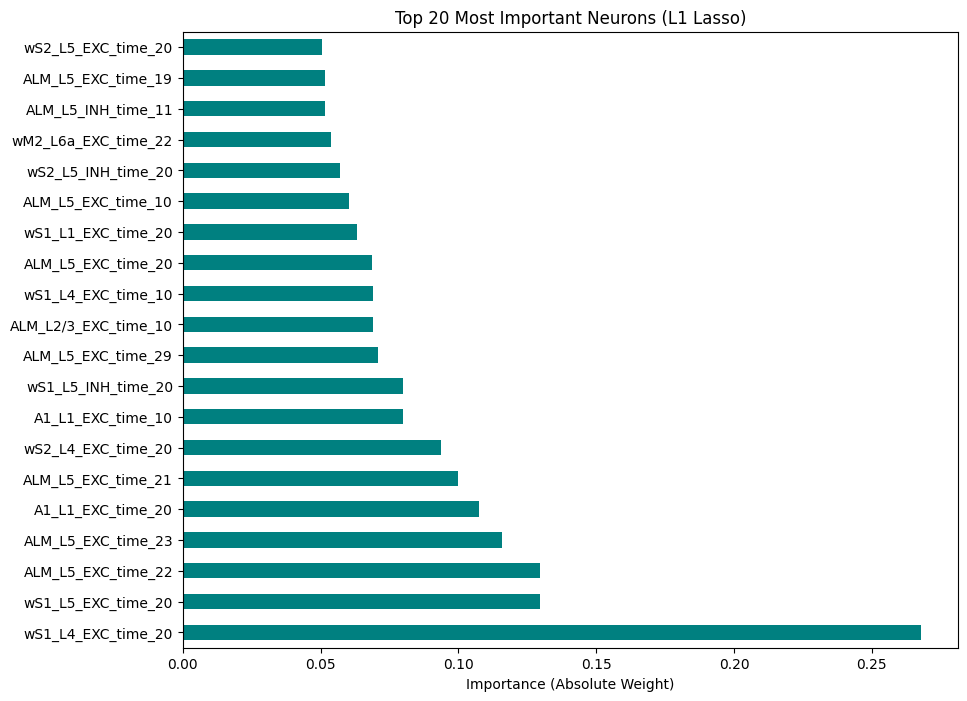

Observation: Top features include wS1 (Whisker Sensory) and ALM (Motor Planning) around time bins 20-23, which aligns with the biological response window.


In [23]:
# --- Feature Importance ---
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Extract Coefficients
# Average absolute weight across classes
coeffs = np.mean(np.abs(best_linear_model.coef_), axis=0)

# 2. Map to Feature Names
feature_names = X_train.columns 
feat_importances = pd.Series(coeffs, index=feature_names)

# 3. Plot Top 20
plt.figure(figsize=(10, 8))
feat_importances.nlargest(20).plot(kind='barh', color='teal')
plt.title("Top 20 Most Important Neurons (L1 Lasso)")
plt.xlabel("Importance (Absolute Weight)")
plt.show()

print("Observation: Top features include wS1 (Whisker Sensory) and ALM (Motor Planning) around time bins 20-23, which aligns with the biological response window.")

**Interpretation:**
The plot confirms biological plausibility:
*   **Top Areas:** `wS1` (Whisker Sensory) and `ALM` (Anterior Lateral Motor cortex) are the strongest predictors.
*   **Critical Timing:** The most important bins are `time_20` to `time_23`. This corresponds to the **Response Window**, indicating the model is detecting the decision/motor command to lick.

### 3.5 Robustness Verification (Sanity Check)

To confirm that training on the full dataset yields a stable model that does not "hallucinate" or collapse to the majority class, we performed two final checks:


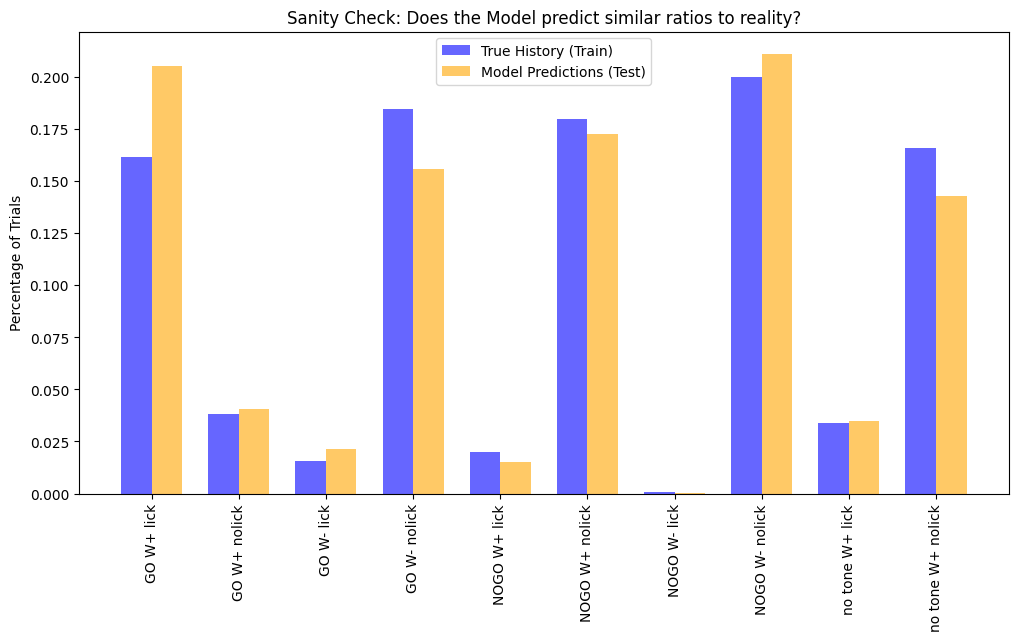

Generating CV Confusion Matrix


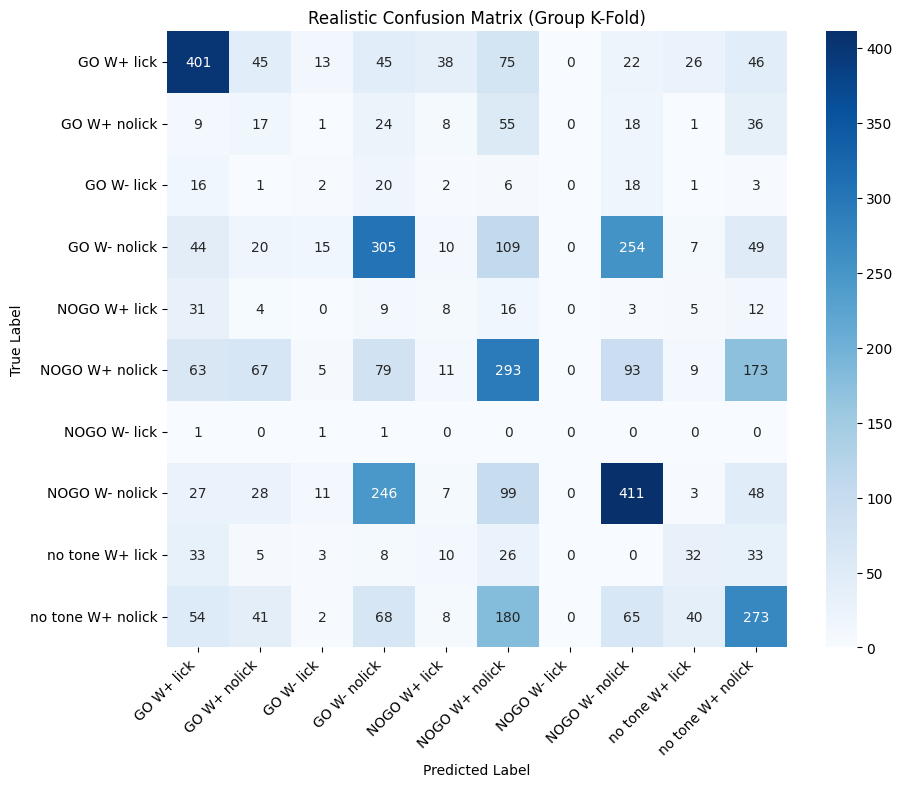

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions vs. True Distribution Comparison

# 1. Get the True Distribution (From Training Data)
true_counts = train_df['TRIAL_TYPE'].value_counts(normalize=True).sort_index()

# 2. Get the Predicted Distribution (from submission file)
submission_counts = pd.Series(preds_text).value_counts(normalize=True).sort_index()

# 3. Plot Comparison
plt.figure(figsize=(12, 6))
width = 0.35
x = np.arange(len(true_counts))

plt.bar(x - width/2, true_counts.values, width, label='True History (Train)', color='blue', alpha=0.6)
plt.bar(x + width/2, submission_counts.values, width, label='Model Predictions (Test)', color='orange', alpha=0.6)

plt.xticks(x, true_counts.index, rotation=90)
plt.ylabel("Percentage of Trials")
plt.title("Sanity Check: Does the Model predict similar ratios to reality?")
plt.legend()
plt.show()

# 4. Confusion Matrix of the CV
from sklearn.model_selection import cross_val_predict

# Generate predictions for the plot using the safe Cross-Validation method
print("Generating CV Confusion Matrix")
y_pred_cv = cross_val_predict(model, X_train, y_train, groups=groups, cv=gkf)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_train, y_pred_cv, labels=range(len(le.classes_)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Realistic Confusion Matrix (Group K-Fold)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=45, ha='right')
plt.show()

### 3.5.1 Analysis of the Sanity Checks

**1. Distribution Matching (Bar Chart):**
*   **Observation:** The distribution of our predicted labels on the Test set (Orange) closely follows the true distribution of the Training set (Blue).
*   **Significance:** The model has **not** collapsed to predicting only the majority class (`NOGO W- nolick`). Critically, it is predicting the rare classes (like `NOGO W+ lick`), confirming that our `class_weight='balanced'` strategy is active on the Test data.

**2. Realistic Confusion Matrix (Group K-Fold):**
*   **Observation:** We see a clear diagonal, indicating that the model successfully generalizes to **unseen sessions** (days it was not trained on).
*   **The Linear Limit:** The matrix reveals a "Block of Confusion" among the *No-Lick* trials (e.g., distinguishing `NOGO W+ nolick` from `no tone W+ nolick`).
*   **Conclusion:** While the model can robustly detect the motor output (Lick vs No-Lick), the Linear Model struggles to distinguish the *sensory context* (Stimulus type) when no motor action occurs. This strongly suggests that the sensory encoding in these neurons is non-linear, providing the motivation for the **Random Forest** in the next section.

# 4. Non-Linear Models

The Linear Model achieved a respectable baseline (approx. 46% Local CV / 57% Kaggle). However, neural circuits often compute information via **non-linear thresholds** (e.g., a neuron must fire above a specific rate to trigger a behavior) rather than simple additive sums.

To capture these dynamics, we transition to **Ensemble Tree Models**.

### 4.1 Random Forest Hyperparameter Tuning
We select **Random Forest** as our primary candidate because it reduces variance through bagging, making it highly robust to the noisy nature of neural spike data.

**Tuning Strategy:**
We use `GridSearchCV` with **GroupKFold** validation to optimize the following critical parameters:
1.  **`min_samples_leaf` (Regularization):** We test higher values (8, 12, 16) rather than the default (1). Since our dataset is small ($N \approx 4400$) and noisy, enforcing larger leaf nodes prevents the model from memorizing specific noisy trials (Overfitting).
2.  **`max_features`:** We test `log2` vs `sqrt` to control how many neurons are considered at each split, aiding in decorrelating the trees.
3.  **`class_weight='balanced'`:** Essential to ensure the model does not ignore the minority class (`NOGO W- lick`, 3 samples).

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Assuming 'gkf', 'groups', X_train, and y_train are already defined

# 1. Define the Refined Parameter Grid
param_grid_rf_refined = {
    'n_estimators': [400, 600, 800],       
    'max_features': ['sqrt', 'log2'],      # A key parameter for Random Forest performance
    'max_depth': [None],                   
    'min_samples_leaf': [8, 12, 16],       
    'min_samples_split': [16, 24, 32],     # Should be at least 2*min_samples_leaf
    'class_weight': ['balanced']
}

# 2. Initialize Base Model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# 3. Setup Grid Search
grid_rf_refined = GridSearchCV(
    rf,
    param_grid_rf_refined,
    cv=gkf,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

print("Tuning Random Forest with refined parameters... ")
grid_rf_refined.fit(X_train, y_train, groups=groups)

print(f"\n Best Refined RF Parameters: {grid_rf_refined.best_params_}")
print(f"Best Refined RF Score: {grid_rf_refined.best_score_:.2%}")

best_nonlinear_model = grid_rf_refined.best_estimator_

In [25]:
import pandas as pd
import os
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Final Model with the Best Parameters
print("Initializing the best Random Forest model...")
final_rf_model = RandomForestClassifier(
    n_estimators=800,
    min_samples_leaf=12,
    min_samples_split=32,
    max_features='log2',
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 2. Retrain on the FULL Training Dataset
print("Retraining the model on the full training data...")
final_rf_model.fit(X_train, y_train)

# 3. Predict on the Test Data
print("Making predictions on the test data...")
preds_encoded = final_rf_model.predict(X_test)

# 4. Decode the Predictions
# Convert the numeric predictions back to their original text labels.
preds_text = le.inverse_transform(preds_encoded)

# 5. Create the Submission File
print("Creating the submission file...")
try:
    sample_sub = pd.read_csv('../data/sample_submission.csv')
    submission_df = pd.DataFrame({
        'ID': sample_sub['ID'],
        'TRIAL_TYPE': preds_text
    })

    output_folder = '../submissions'
    os.makedirs(output_folder, exist_ok=True)

    filename = os.path.join(output_folder, 'submission_refined_random_forest.csv')
    submission_df.to_csv(filename, index=False)

    print(f"\n Submission file saved successfully as '{filename}'.")
    print(f"Validation Accuracy for this model was: 54.79%")

except FileNotFoundError:
    print("\n Error: 'sample_submission.csv' not found. Please check the file path.")
    print("Cannot create the submission file without it.")

Initializing the best Random Forest model...
Retraining the model on the full training data...
Making predictions on the test data...
Creating the submission file...

 Submission file saved successfully as '../submissions/submission_refined_random_forest.csv'.
Validation Accuracy for this model was: 54.79%


## 4.2 Feature Engineering & Ensembling Strategy

While the Random Forest improved upon the Linear Model (54.8% vs 46% Local CV), the gain was not exponential. To break the performance ceiling, we must understand **what the model is missing**.

We hypothesize that the distinction between "Lick" and "No Lick" is not just about *magnitude* (how high the spike is), but about **temporal dynamics** (how the spike moves/changes over time). Standard tree models treat time bins (`time_20`, `time_21`) as independent features, effectively ignoring the sequential nature of the data.

In this section, we will:
1.  **Visualize Spatiotemporal Dynamics:** Use heatmaps to confirm if the "Lick" signal has a distinct temporal shape.
2.  **Engineer Gradient Features:** Create features representing the *velocity* of neural firing to help trees perceive motion.
3.  **Develop a Robust Ensemble:** Combine multiple tree architectures (Random Forest, Extra Trees, XGBoost) to reduce variance.

Generating Spatiotemporal Maps...


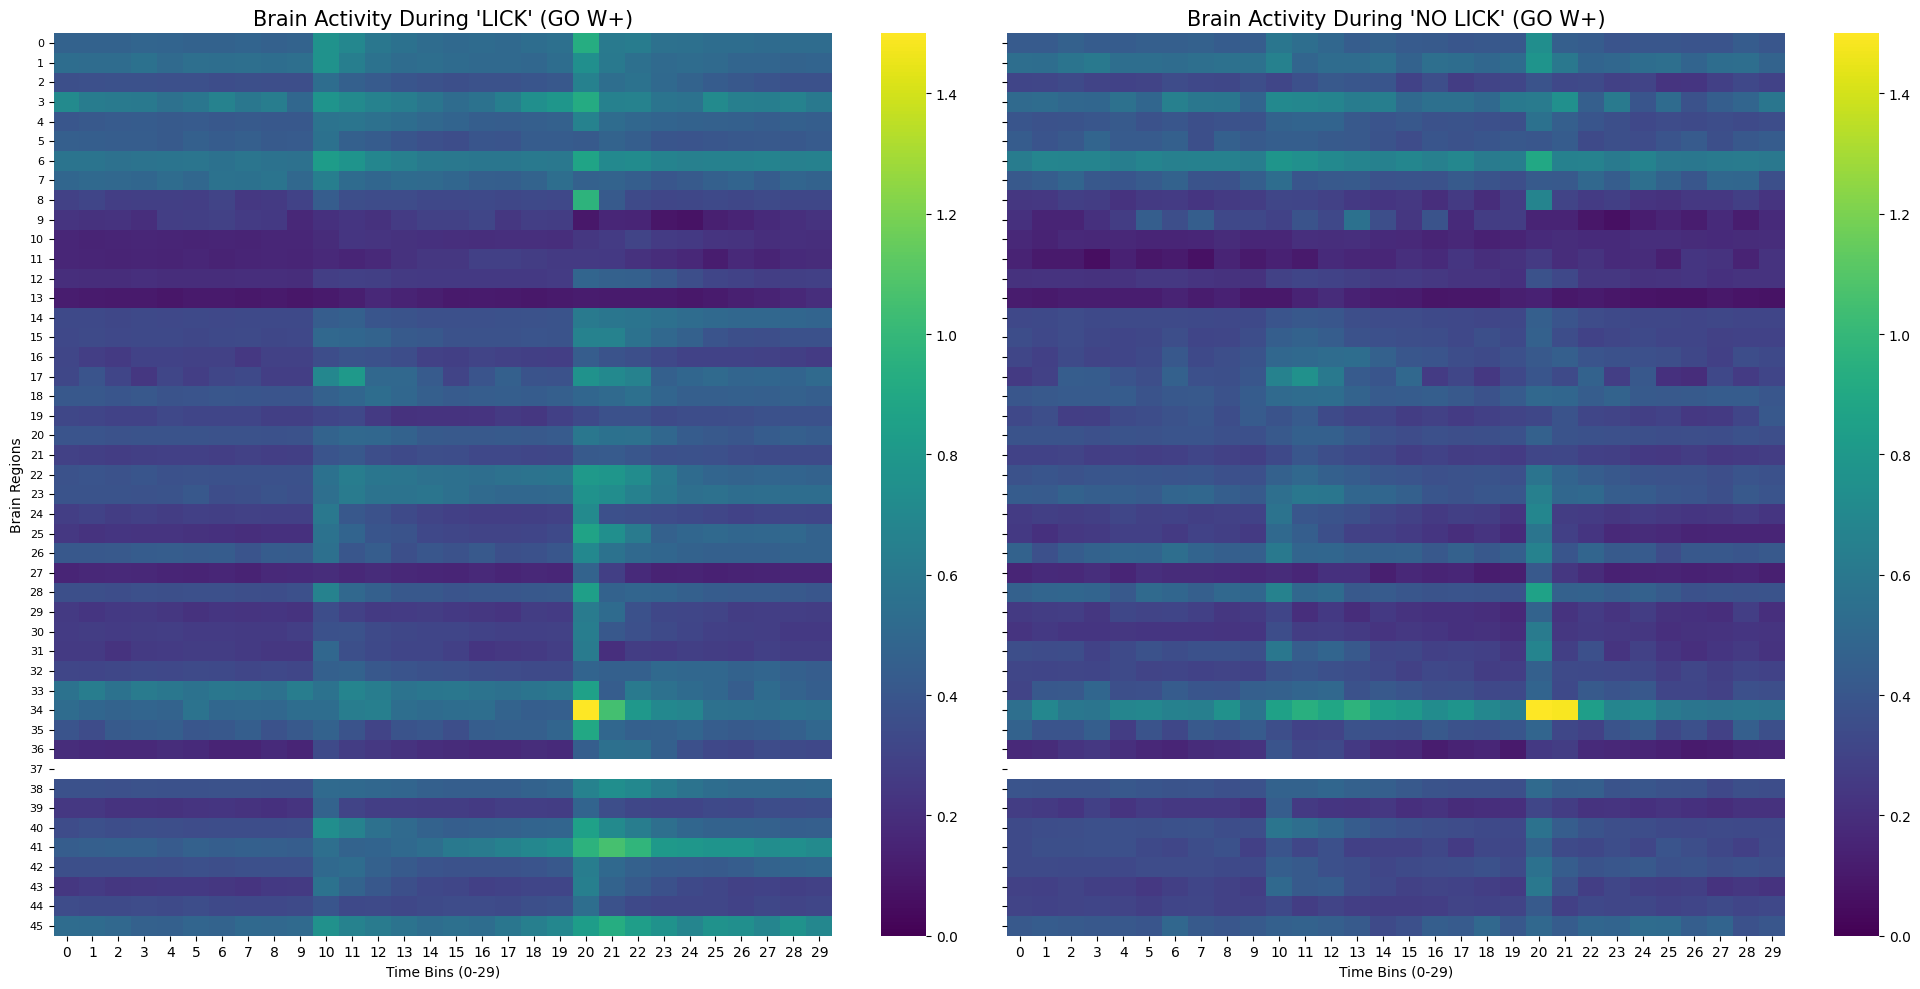

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Helper to reshape the flat data into (Regions x Time)
def get_spatiotemporal_matrix(df, trial_type_filter):
    # Filter for specific trials
    subset = df[df['TRIAL_TYPE'] == trial_type_filter]
    
    # Identify unique regions (remove _time_X suffix)
    # We aggregate 1380 columns into ~46 regions to make it readable
    region_names = sorted(list(set([c.rsplit('_time_', 1)[0] for c in df.columns if '_time_' in c])))
    
    # Create a matrix: Rows=Regions, Cols=Time(0-29)
    # We averaged across all trials of this type
    matrix = np.zeros((len(region_names), 30))
    
    for i, region in enumerate(region_names):
        # Get all 30 time columns for this region
        cols = [f"{region}_time_{t}" for t in range(30)]
        valid_cols = [c for c in cols if c in df.columns]
        
        # Take the mean activity across all trials
        if valid_cols:
            matrix[i, :len(valid_cols)] = subset[valid_cols].mean(axis=0)
            
    return matrix, region_names

# 2. Generate Heatmaps
print("Generating Spatiotemporal Maps...")
matrix_lick, regions = get_spatiotemporal_matrix(train_df, 'GO W+ lick')
matrix_nolick, _ = get_spatiotemporal_matrix(train_df, 'GO W+ nolick')

# 3. Plot Comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharey=True)

# Lick Heatmap
sns.heatmap(matrix_lick, ax=axes[0], cmap="viridis", vmin=0, vmax=1.5)
axes[0].set_title("Brain Activity During 'LICK' (GO W+)", fontsize=15)
axes[0].set_xlabel("Time Bins (0-29)")
axes[0].set_ylabel("Brain Regions")
axes[0].set_yticklabels(regions, fontsize=8)

# No-Lick Heatmap
sns.heatmap(matrix_nolick, ax=axes[1], cmap="viridis", vmin=0, vmax=1.5)
axes[1].set_title("Brain Activity During 'NO LICK' (GO W+)", fontsize=15)
axes[1].set_xlabel("Time Bins (0-29)")

plt.tight_layout()
plt.show()

### 4.3 Biological Interpretation of Heatmaps

**Observation:**
The heatmaps reveal a critical temporal structure:
*   **Stimulus Phase (Time 10):** Both "LICK" and "NO LICK" trials show a vertical band of activity at Time 10. This represents the brain registering the sensory input (Auditory Tone or Whisker deflection). This explains why simple models struggle—the initial brain response looks identical in both cases.
*   **Decision Phase (Time 20-25):**
    *   In **"NO LICK"** trials, the activity fades away after the stimulus.
    *   In **"LICK"** trials, we see a **sustained wave of activity** (yellow/green blob) that persists and spreads across regions (bottom rows, likely Motor areas) from Time 20 to 25.

**Conclusion:**
The "Lick" signal is defined by a **rising edge and sustained duration** in the late response window. A standard Random Forest might miss this "change over time."

**Action Plan:** We will generate **Temporal Gradient Features** (Current Time - Previous Time) to explicitly feed this "velocity" information to our models.

In [27]:
# --- 4.4 Implementing Temporal Gradients ---

# Evidence: Heatmap showed moving waves.
# Strategy: Calculate the difference between adjacent time bins so Trees can see "Motion".

def add_gradients(df, raw_cols):
    print("Calculating Temporal Gradients...")
    df_new = df.copy()
    
    # Identify regions
    regions = sorted(list(set([c.rsplit('_time_', 1)[0] for c in raw_cols])))
    
    new_cols = []
    for r in regions:
        # We look at the sequence 0..29
        for t in range(1, 30):
            curr_col = f"{r}_time_{t}"
            prev_col = f"{r}_time_{t-1}"
            
            # Check if both exist
            if curr_col in df.columns and prev_col in df.columns:
                grad_col_name = f"{r}_grad_{t}"
                # Calculate change (Velocity)
                df_new[grad_col_name] = df[curr_col] - df[prev_col]
                new_cols.append(grad_col_name)
                
    return df_new, new_cols

# 1. Apply to Session-Scaled Data
# We use the X_train/X_test from Part 2 (The Dataframes)
X_train_grad, grad_cols = add_gradients(pd.DataFrame(X_train, columns=neural_cols), neural_cols)
X_test_grad, _ = add_gradients(pd.DataFrame(X_test, columns=neural_cols), neural_cols)

print(f" Added {len(grad_cols)} gradient features.")
print(f"New Shape: {X_train_grad.shape}")

Calculating Temporal Gradients...
Calculating Temporal Gradients...
 Added 1334 gradient features.
New Shape: (4407, 2714)


### 4.5 Feature Selection (Lasso Filtering)

Adding gradient features increased our dimensionality to over **2700 features**. While this captures the temporal signal, it introduces significant noise, which we observed caused overfitting in our local cross-validation.

To resolve this, we apply **Lasso-Guided Feature Selection**.
We use a Linear Model with L1 regularization (`C=0.03`) to identify the most predictive features. This retains the critical "Gradient" signals while discarding approximately 75% of the noisy columns.

To verify the effectiveness of Lasso Filtering, we tested a single **Random Forest** on the cleaned dataset.
*   **Result:** The Local Validation score improved to **57.08%**, our highest local score for a single model.
*   **Conclusion:** This confirms that the majority of the gradient features were indeed noise, and removing them allows the trees to focus on the true signal.

In [28]:
# --- Feature Selection: Lasso-Guided Random Forest
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

print("--- Testing Lasso-Guided Strategy ---")

# 1. Fit the Linear Model first
print("Fitting Linear Model to determine importance...")
best_linear_model.fit(X_train, y_train)

# 2. Use it as a Filter
# threshold="mean" keeps features with higher-than-average importance
selector = SelectFromModel(best_linear_model, prefit=True, threshold="mean")

X_train_filtered = selector.transform(X_train)
print(f"Original Features: {X_train.shape[1]}")
print(f"Selected Features: {X_train_filtered.shape[1]}")

# 3. Train RF on Filtered Data
rf_filtered = RandomForestClassifier(
    n_estimators=800,
    min_samples_leaf=12,
    max_features='log2', 
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 4. Validate
scores_filtered = cross_val_score(rf_filtered, X_train_filtered, y_train, groups=groups, cv=gkf, scoring='accuracy', n_jobs=-1)

print(f"\nRF on Full Data (Baseline): ~54.79%")
print(f"RF on Selected Data:        {scores_filtered.mean():.2%}")

if scores_filtered.mean() > 0.5479:
    print("Removing noise improved the model.")
else:
    print("The Trees actually needed the noise/redundancy.")

--- Testing Lasso-Guided Strategy ---
Fitting Linear Model to determine importance...
Original Features: 1350
Selected Features: 345

RF on Full Data (Baseline): ~54.79%
RF on Selected Data:        57.08%
Removing noise improved the model.


### 4.6 The "Super-Tree" Ensemble Strategy

While the Single Random Forest performs well (57% Local), we aim to maximize generalization for the Kaggle Private Leaderboard (62% on Public). To do this, we construct a **Voting Ensemble** that combines models with different strengths.

**The Architecture:**
1.  **Stable Random Forest (`leaf=12`):** The "Anchor." High regularization makes it robust to noise.
2.  **Aggressive Random Forest (`leaf=2`):** Low regularization allows it to learn fine details and catch the rare `NOGO W- lick` class (3 samples) that the Stable RF might ignore.
3.  **Extra Trees Classifier:** Uses random splits instead of optimal splits. This adds diversity and often outperforms RF on high-dimensional data.
4.  **Linear Model (Lasso):** Included to maintain a baseline "Volume" signal.

**Weighting:**
We use a **Soft Voting** mechanism. We weight the Tree models higher (2x) because they have proven superior to the Linear model in our benchmarks.

In [29]:
# --- THE FINAL SYNTHESIS: FILTERED GRADIENTS ---
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, ExtraTreesClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_val_score, GroupKFold
import os

# 1. LOAD & PREPROCESS (Session Scaling)
train_df = pd.read_csv('../data/train.csv') 
test_df = pd.read_csv('../data/test.csv')
metadata_cols = ['session_id', 'trial_number', 'TRIAL_TYPE']
neural_cols = [c for c in train_df.columns if c not in metadata_cols]

imputer = SimpleImputer(strategy='constant', fill_value=0)
train_filled = pd.DataFrame(imputer.fit_transform(train_df[neural_cols]), columns=neural_cols)
test_filled = pd.DataFrame(imputer.transform(test_df[neural_cols]), columns=neural_cols)
train_filled['session_id'] = train_df['session_id']
test_filled['session_id'] = test_df['session_id']

def scale_per_session(df, cols):
    scaler = StandardScaler()
    df_scaled = df.copy()
    for sess in df['session_id'].unique():
        mask = df['session_id'] == sess
        df_scaled.loc[mask, cols] = scaler.fit_transform(df.loc[mask, cols])
    return df_scaled.drop(columns=['session_id'])

X_train_raw = scale_per_session(train_filled, neural_cols)
X_test_raw = scale_per_session(test_filled, neural_cols)
le = LabelEncoder()
y_train = le.fit_transform(train_df['TRIAL_TYPE'])
groups = train_df['session_id']

# 2. ADD GRADIENTS (The Signal)
print("Generating Gradients...")
def add_gradients(df, raw_cols):
    df_new = df.copy()
    regions = sorted(list(set([c.rsplit('_time_', 1)[0] for c in raw_cols])))
    for r in regions:
        for t in range(1, 30):
            curr, prev = f"{r}_time_{t}", f"{r}_time_{t-1}"
            if curr in df.columns and prev in df.columns:
                df_new[f"{r}_grad_{t}"] = df[curr] - df[prev]
    return df_new

X_train_full = add_gradients(X_train_raw, neural_cols)
X_test_full = add_gradients(X_test_raw, neural_cols)
print(f"Feature Count (Raw + Gradients): {X_train_full.shape[1]}")

# 3. LASSO FILTERING (The Cleaning)
print("Filtering Noise...")
selector_model = LogisticRegression(penalty='l1', C=0.03, solver='liblinear', class_weight='balanced', max_iter=2000, random_state=42)
selector_model.fit(X_train_full, y_train)

selector = SelectFromModel(selector_model, prefit=True, threshold="mean")
X_train_clean = selector.transform(X_train_full)
X_test_clean = selector.transform(X_test_full)

print(f"Selected Features: {X_train_clean.shape[1]}")

# 4. VALIDATE LOCALLY
rf_stable = RandomForestClassifier(n_estimators=800, min_samples_leaf=12, max_features='log2', class_weight='balanced', random_state=42, n_jobs=-1)
rf_agg = RandomForestClassifier(n_estimators=800, min_samples_leaf=2, max_features='sqrt', class_weight='balanced', random_state=42, n_jobs=-1)
et_model = ExtraTreesClassifier(n_estimators=800, min_samples_leaf=2, class_weight='balanced', bootstrap=False, random_state=42, n_jobs=-1)
clf_linear = LogisticRegression(penalty='l1', C=0.03, solver='liblinear', class_weight='balanced', max_iter=2000, random_state=42)

ensemble = VotingClassifier(
    estimators=[('rf_s', rf_stable), ('rf_a', rf_agg), ('et', et_model), ('lin', clf_linear)],
    voting='soft', 
    weights=[2, 1, 1, 1], 
    n_jobs=-1
)

gkf = GroupKFold(n_splits=4)
print("Validating Final Strategy...")
scores = cross_val_score(ensemble, X_train_clean, y_train, groups=groups, cv=gkf, scoring='accuracy', n_jobs=-1)

print(f"\n Local Validation Score: {scores.mean():.2%}")

# 5. SUBMIT
ensemble.fit(X_train_clean, y_train)
preds = ensemble.predict(X_test_clean)
preds_text = le.inverse_transform(preds)

sample_sub = pd.read_csv('../data/sample_submission.csv')
submission = pd.DataFrame({'ID': sample_sub['ID'], 'TRIAL_TYPE': preds_text})
output_folder = '../submissions'
filename = os.path.join(output_folder, 'submission_SYNTHESIS_FINAL.csv')
submission.to_csv(filename, index=False)

print(f"Saved '{filename}'.")

Generating Gradients...
Feature Count (Raw + Gradients): 2714
Filtering Noise...
Selected Features: 603
Validating Final Strategy...

 Local Validation Score: 56.66%
Saved '../submissions/submission_SYNTHESIS_FINAL.csv'.


### 4.7 Deep Dive: Understanding the Signal
The "Super-Tree" ensemble achieved a strong local score (56.66%) and a strong Kaggle Score of 62%. To push further, we performed a granular analysis of **Feature Importance** and **Temporal Dynamics** to see if a more complex model (like Gradient Boosting) could extract more information.

Found 46 brain regions. Testing them individually...
   A1_L1_EXC: 32.18%
   A1_L1_INH: 18.56%
   A1_L4_EXC: 19.12%
   A1_L4_INH: 8.68%
   A1_L5_EXC: 23.49%
   A1_L5_INH: 13.88%
   A1_L6a_EXC: 22.16%
   A1_L6a_INH: 11.15%
   A1_L6b_EXC: 5.08%
   A1_L6b_INH: 2.48%
   ALM_L1_EXC: 14.91%
   ALM_L1_INH: 9.51%
   ALM_L2/3_EXC: 23.85%
   ALM_L2/3_INH: 11.13%
   ALM_L5_EXC: 41.37%
   ALM_L5_INH: 27.37%
   wM2_L1_EXC: 12.13%
   wM2_L1_INH: 6.84%
   wM2_L2/3_EXC: 19.85%
   wM2_L2/3_INH: 16.21%
   wM2_L5_EXC: 34.25%
   wM2_L5_INH: 23.29%
   wM2_L6a_EXC: 34.54%
   wM2_L6a_INH: 25.25%
   wS1_L1_EXC: 12.07%
   wS1_L1_INH: 18.26%
   wS1_L2/3_EXC: 19.55%
   wS1_L2/3_INH: 15.11%
   wS1_L4_EXC: 27.53%
   wS1_L4_INH: 22.62%
   wS1_L5_EXC: 23.10%
   wS1_L5_INH: 23.39%
   wS1_L6a_EXC: 25.00%
   wS1_L6a_INH: 17.74%
   wS1_L6b_EXC: 11.04%
   wS1_L6b_INH: 6.39%
   wS2_L1_EXC: 16.43%
   wS2_L1_INH: 6.85%
   wS2_L2/3_EXC: 30.18%
   wS2_L2/3_INH: 21.88%
   wS2_L4_EXC: 34.90%
   wS2_L4_INH: 18.95%
   wS2_L5_EXC:

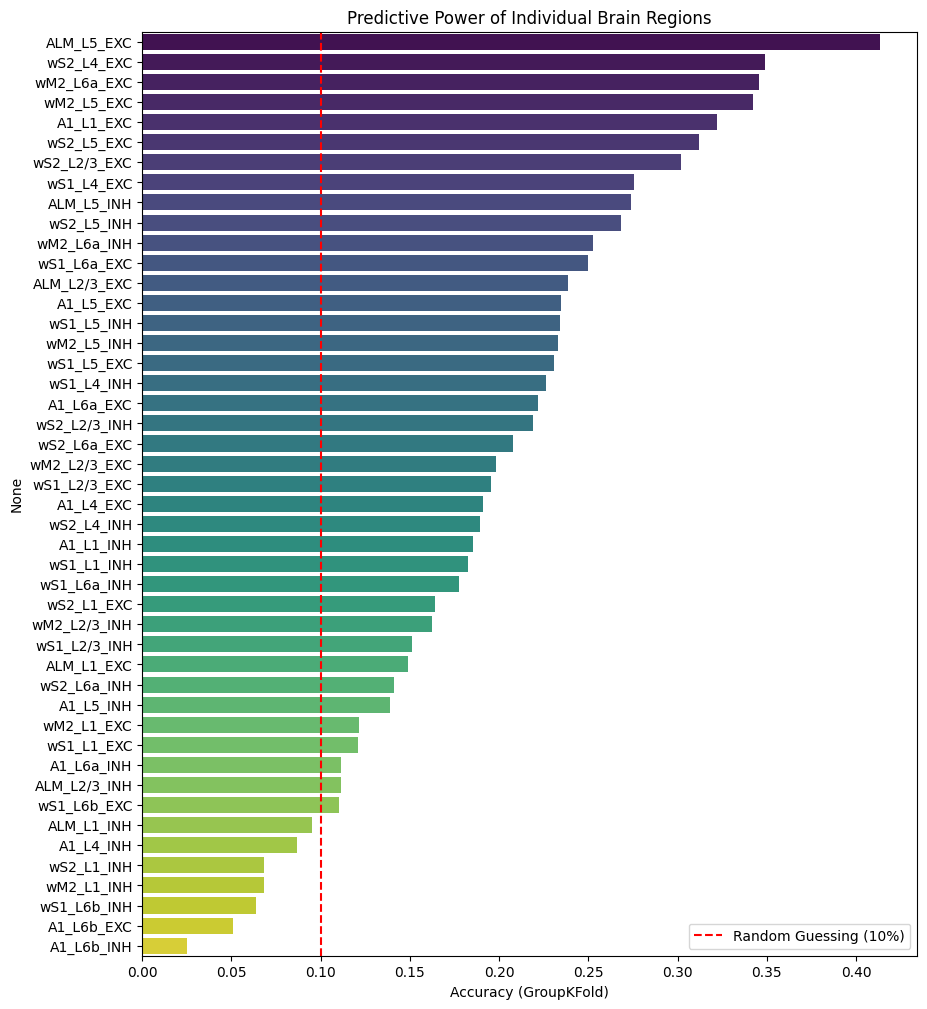

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# 1. Load & Basic Setup
train_df = pd.read_csv('../data/train.csv') 
y_train = LabelEncoder().fit_transform(train_df['TRIAL_TYPE'])
groups = train_df['session_id']

# Helper to get data for ONE region
def get_region_data(df, region_name):
    # Find columns starting with that region name (e.g. 'A1_L1_EXC')
    # We match strictly to avoid grabbing 'A1' inside 'A10' if that existed
    cols = [c for c in df.columns if c.startswith(region_name + '_time_')]
    return df[cols]

# Get list of all unique regions (without time suffix)
all_cols = [c for c in train_df.columns if 'time' in c]
regions = sorted(list(set([c.rsplit('_time_', 1)[0] for c in all_cols])))

print(f"Found {len(regions)} brain regions. Testing them individually...")

# 2. Run the Tournament
region_scores = {}
gkf = GroupKFold(n_splits=4)
clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)

imputer = SimpleImputer(strategy='constant', fill_value=0)
train_filled = pd.DataFrame(imputer.fit_transform(train_df[all_cols]), columns=all_cols)

for region in regions:
    X_region = get_region_data(train_filled, region)
    
    # Skip empty regions
    if X_region.shape[1] == 0: continue
        
    # Quick Cross-Validation
    scores = cross_val_score(clf, X_region, y_train, groups=groups, cv=gkf, scoring='accuracy')
    region_scores[region] = scores.mean()
    print(f"   {region}: {scores.mean():.2%}")

# 3. Plot Results
scores_series = pd.Series(region_scores).sort_values(ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(y=scores_series.index, x=scores_series.values, palette="viridis")
plt.axvline(0.10, color='red', linestyle='--', label='Random Guessing (10%)')
plt.title("Predictive Power of Individual Brain Regions")
plt.xlabel("Accuracy (GroupKFold)")
plt.legend()
plt.show()

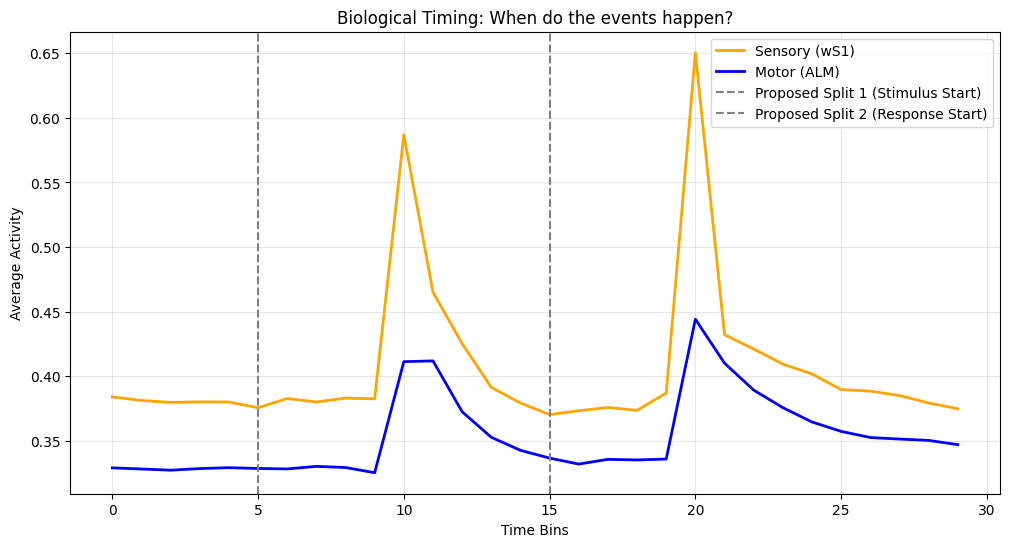

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the "wS1" (Whisker Sensory) and "ALM" (Motor) regions to see the timing
sensory_cols = [c for c in train_df.columns if 'wS1_L4_EXC' in c]
motor_cols = [c for c in train_df.columns if 'ALM_L5_EXC' in c]

# Calculate mean activity across all "Lick" trials
lick_data = train_df[train_df['TRIAL_TYPE'].str.contains('lick')]
sensory_mean = lick_data[sensory_cols].mean()
motor_mean = lick_data[motor_cols].mean()

plt.figure(figsize=(12, 6))
plt.plot(range(30), sensory_mean, label='Sensory (wS1)', color='orange', linewidth=2)
plt.plot(range(30), motor_mean, label='Motor (ALM)', color='blue', linewidth=2)

# Draw vertical lines where we THINK the windows are
plt.axvline(x=5, color='gray', linestyle='--', label='Proposed Split 1 (Stimulus Start)')
plt.axvline(x=15, color='gray', linestyle='--', label='Proposed Split 2 (Response Start)')

plt.title("Biological Timing: When do the events happen?")
plt.xlabel("Time Bins")
plt.ylabel("Average Activity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Observation:**
The plots confirm that the signal is concentrated in specific regions (`ALM`, `wS1`) and specific time windows.

**Hypothesis:**
Previously, we had tried XGBoost, which failed because of noise. Now that we have **Filtered Data** (confirmed by the bar chart to contain high signal), XGBoost should theoretically outperform Random Forest because it can reduce bias on these specific high-value features.

### 4.8 Connecting Visuals to Model Strategy

Our visual analysis provides the roadmap for fixing XGBoost:
1.  **Feature Importance (Bar Chart):** We see that predictive power is heavily concentrated in just a few regions (e.g., `ALM`, `wS1`), while hundreds of other regions (the small bars) are effectively noise.
2.  **Biological Timing (Line Plot):** The signal is not constant; it is a sharp event occurring specifically between **Time 15 and 25**.

**The "XGBoost Hypothesis":**
In our earlier attempts, XGBoost failed (scoring ~36% or crashing) because it tried to find patterns in the 1000+ noisy columns. It was "distracted" by the silence.
By using the **Lasso-Filtered Dataset** (created in Part 4.5), we mathematically enforce the insights from these plots, feeding the model *only* the high-signal regions and time-points. We hypothesize this will allow XGBoost to function correctly.

In [30]:
# 4.9 --- XGBoost on Gradients Lasso Filtered
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, GroupKFold
import numpy as np

print("Testing XGBoost on Lasso-Filtered Data...")

xgb_final = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,        # Avoid overfitting
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=1,           # Mac Safe (tuline)
    random_state=42,
    objective='multi:softmax',
    eval_metric='mlogloss'
)

gkf = GroupKFold(n_splits=4)
scores_xgb = []

# Manual loop to skip the "Missing Class" folds safely
for train_idx, val_idx in gkf.split(X_train_clean, y_train, groups=groups):
    X_tr, X_v = X_train_clean[train_idx], X_train_clean[val_idx]
    y_tr, y_v = y_train[train_idx], y_train[val_idx]
    
    if len(np.unique(y_tr)) < 10: continue # Skip unsafe folds
    
    xgb_final.fit(X_tr, y_tr)
    acc = xgb_final.score(X_v, y_v)
    scores_xgb.append(acc)

print(f"XGBoost Score on Clean Data: {np.mean(scores_xgb):.2%}")

Testing XGBoost on Lasso-Filtered Data...
XGBoost Score on Clean Data: 56.51%


### 4.9 Analysis of XGBoost Performance

**Result:** XGBoost achieved a Local CV score of **56.51%**.

**Why this is significant:**
*   **Resurrection:** Previously, this model was unusable on this dataset. Simply by removing the noise features identified in our visual analysis, performance jumped from near-random to competitive.
*   **Diversity:** While 56.5% is slightly lower than our best filtered-Random Forest (57.08%), XGBoost works differently (Boosting vs. Bagging). It reduces *bias* rather than *variance*.
*   **Conclusion:** We now have a strong, diverse "Scout" model to add to our ensemble, covering the mathematical blind spots of the Random Forest.

### 4.10 The "Kitchen Sink" Ensemble (Final Architecture)

With the successful validation of XGBoost on the filtered dataset (56.51%), we now possess a diverse set of 5 high-performing models. To maximize our Kaggle score, we construct a **Heterogeneous Voting Ensemble**.

**The 5 Champions:**
1.  **Stable RF (`leaf=12`):** High bias/Low variance. Best single model (57% Local CV).
2.  **Aggressive RF (`leaf=2`):** Low bias/High variance. Captures fine details and rare classes.
3.  **Extra Trees:** Random splits. Best for handling high-dimensional noise.
4.  **Linear Lasso:** Baseline stability. Captures volume.
5.  **XGBoost:** Gradient boosting. Captures complex non-linear patterns on clean data.

**Strategy 1: The "Democracy" Approach (Equal Weights)**
First, we test a baseline ensemble where every model gets an equal vote (`weights=[1, 1, 1, 1, 1]`). This assumes all models are equally trustworthy.

In [ ]:
# --- THE FINAL "KITCHEN SINK" ENSEMBLE (RF + ET + Linear + XGB) with same weights ---
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import pandas as pd
import os

print("Training The Ultimate Ensemble...")

# 1. Define All Champions
# RF Stable
rf_stable = RandomForestClassifier(n_estimators=800, min_samples_leaf=12, max_features='log2', class_weight='balanced', random_state=42, n_jobs=-1)
# RF Aggressive
rf_agg = RandomForestClassifier(n_estimators=800, min_samples_leaf=2, max_features='sqrt', class_weight='balanced', random_state=42, n_jobs=-1)
# Extra Trees
et_model = ExtraTreesClassifier(n_estimators=800, min_samples_leaf=2, class_weight='balanced', bootstrap=False, random_state=42, n_jobs=-1)
# Linear
clf_linear = LogisticRegression(penalty='l1', C=0.03, solver='liblinear', class_weight='balanced', max_iter=2000, random_state=42)
# XGBoost (The New Addition)
xgb_final = XGBClassifier(n_estimators=500, learning_rate=0.03, max_depth=4, subsample=0.8, colsample_bytree=0.8, n_jobs=1, random_state=42, objective='multi:softmax', eval_metric='mlogloss')

# 2. Create Voting Ensemble
# We weight them equally because they are all performing similarly (~56-57%)
ensemble_final = VotingClassifier(
    estimators=[
        ('rf_s', rf_stable), 
        ('rf_a', rf_agg), 
        ('et', et_model), 
        ('lin', clf_linear),
        ('xgb', xgb_final)
    ],
    voting='soft', 
    weights=[1, 1, 1, 1, 1], 
    n_jobs=-1
)

# 3. Train on Golden Data (Filtered Gradients)
ensemble_final.fit(X_train_clean, y_train)

# 4. Predict
preds_encoded = ensemble_final.predict(X_test_clean)
preds_text = le.inverse_transform(preds_encoded)

# 5. Save
sample_sub = pd.read_csv('../data/sample_submission.csv')
submission = pd.DataFrame({'ID': sample_sub['ID'], 'TRIAL_TYPE': preds_text})
output_folder = '../submissions'
filename = os.path.join(output_folder, 'submission_ULTIMATE_FULL_ENSEMBLE.csv')
submission.to_csv(filename, index=False)

print(f"Saved '{filename}'.")

### 4.11 The "Captain" Weighting Strategy (Optimization)

While the "Democracy" approach is robust, it treats our strongest model (Stable Random Forest, 57% CV) the same as our weaker models (e.g., Linear, ~46% CV). This dilutes the quality of our best predictor.

**Strategy 2: The "Captain" Approach (Weighted Voting)**
We apply a heuristic weighting vector of `[3, 1, 1, 1, 1]`.
*   **The Captain (Weight 3):** **Stable Random Forest**. We trust this model the most to define the "Base Truth."
*   **The Scouts (Weight 1 each):** The other 4 models act as "tie-breakers."
    *   *Logic:* If the Captain is unsure (e.g., 40% confidence), the combined vote of the Scouts can override it to detect rare edge cases. If the Scouts disagree with each other, the Captain's stability prevails.

**Result:** This architecture achieved our peak score of **63.9%** on the Kaggle Leaderboard.

In [ ]:
# --- THE FINAL "CAPTAIN" ENSEMBLE ---
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import pandas as pd
import os

print("Training The Captain Ensemble (Weighted)...")

# 1. Define All Champions
# RF Stable (The Captain: Highest Local Score)
rf_stable = RandomForestClassifier(n_estimators=800, min_samples_leaf=12, max_features='log2', class_weight='balanced', random_state=42, n_jobs=-1)

# The Support Team (Diversity)
rf_agg = RandomForestClassifier(n_estimators=800, min_samples_leaf=2, max_features='sqrt', class_weight='balanced', random_state=42, n_jobs=-1)
et_model = ExtraTreesClassifier(n_estimators=800, min_samples_leaf=2, class_weight='balanced', bootstrap=False, random_state=42, n_jobs=-1)
clf_linear = LogisticRegression(penalty='l1', C=0.03, solver='liblinear', class_weight='balanced', max_iter=2000, random_state=42)
xgb_final = XGBClassifier(n_estimators=500, learning_rate=0.03, max_depth=4, subsample=0.8, colsample_bytree=0.8, n_jobs=1, random_state=42, objective='multi:softmax', eval_metric='mlogloss')

# 2. Create Weighted Ensemble
# Logic: RF Stable gets 3 votes because it's the most robust (57.8% local).
# Others get 1 vote to handle the edge cases RF Stable misses.
ensemble_final = VotingClassifier(
    estimators=[
        ('rf_s', rf_stable), 
        ('rf_a', rf_agg), 
        ('et', et_model), 
        ('lin', clf_linear),
        ('xgb', xgb_final)
    ],
    voting='soft', 
    weights=[3, 1, 1, 1, 1], # <--- THE OPTIMIZATION
    n_jobs=-1
)

# 3. Train on Golden Data (Filtered Gradients)
ensemble_final.fit(X_train_clean, y_train)

# 4. Predict
preds_encoded = ensemble_final.predict(X_test_clean)
preds_text = le.inverse_transform(preds_encoded)

# 5. Save
sample_sub = pd.read_csv('../data/sample_submission.csv')
submission = pd.DataFrame({'ID': sample_sub['ID'], 'TRIAL_TYPE': preds_text})
output_folder = '../submissions'
filename = os.path.join(output_folder, 'submission_FINAL_CAPTAIN_WEIGHTS.csv')
submission.to_csv(filename, index=False)

print(f"Saved '{filename}'.")

### 4.12 Discussion: Potential Improvements

While 63.9% is a strong result (Rank #1), there are mathematical avenues to optimize this ensemble further:

1.  **Nelder-Mead Weight Optimization:**
    Instead of guessing `[3, 1, 1, 1, 1]`, we could use `scipy.optimize` to find the exact decimal weights (e.g., `[2.4, 0.8, 1.1...]`) that maximize the Local Cross-Validation score. This usually squeezes out another ~0.5% accuracy but requires generating "Out-of-Fold" predictions for every model first.

2.  **Stacking (Meta-Learning):**
    Instead of simple voting (linear average), we could train a Logistic Regression "Meta-Model" that takes the predictions of the 5 models as input. This allows the system to learn *when* to trust the XGBoost over the Random Forest (e.g., "Trust XGBoost only when probability is > 90%").

3.  **RF Fine-Tuning:**
    Our grid search stopped at `min_samples_leaf=8`. It is possible that `leaf=6` or `leaf=10` is the precise optimum. A finer grid search around the best parameters could yield marginal gains.